# DEEP NEURAL NETWORKS - ASSIGNMENT 2: CNN FOR IMAGE CLASSIFICATION

## Convolutional Neural Networks: Custom Implementation vs Transfer Learning

STUDENT INFORMATION (REQUIRED - DO NOT DELETE)

BITS ID: 2025AA05327

Name: Anirban Sen

Email: 2025aa05327@wilp.bits-pilani.ac.in

Date: Jan 25, 2026

In [ ]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import time
import json
import os

In [ ]:
# Deep learning frameworks (choose Keras or PyTorch)
# For image processing
from PIL import Image
import cv2

### 1.1 Dataset Selection and Loading



In [ ]:
# Download dogs-vs-cats dataset
! kaggle competitions download -c dogs-vs-cats

 99% 802M/812M [00:04<00:00, 106MB/s]
100% 812M/812M [00:04<00:00, 173MB/s]


In [ ]:
# Unzip the dataset
import zipfile

# Define paths
main_zip_file_path = '/content/dogs-vs-cats.zip'
main_extraction_path = '/content/'

train_zip_file_path = os.path.join(main_extraction_path, 'train.zip')
train_extraction_path = os.path.join(main_extraction_path, 'train')

test_zip_file_path = os.path.join(main_extraction_path, 'test1.zip')
test_extraction_path = os.path.join(main_extraction_path, 'test1')

# 1. Extract the main dogs-vs-cats.zip
# This will place train.zip, test1.zip, and sampleSubmission.csv into /content/
if not os.path.exists(train_zip_file_path): # Check if contents are already extracted
    print(f"Extracting {main_zip_file_path} to {main_extraction_path}")
    with zipfile.ZipFile(main_zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(main_extraction_path)
else:
    print(f"'{main_zip_file_path}' contents (train.zip, test1.zip) already exist in {main_extraction_path}. Skipping main extraction.")

# 2. Extract train.zip
if not os.path.exists(train_extraction_path):
    os.makedirs(train_extraction_path, exist_ok=True)
    print(f"Extracting {train_zip_file_path} to {train_extraction_path}")
    with zipfile.ZipFile(train_zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(train_extraction_path)
else:
    print(f"'{train_extraction_path}' already exists. Skipping extraction of train.zip.")

# 3. Extract test1.zip
if not os.path.exists(test_extraction_path):
    os.makedirs(test_extraction_path, exist_ok=True)
    print(f"Extracting {test_zip_file_path} to {test_extraction_path}")
    with zipfile.ZipFile(test_zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(test_extraction_path)
else:
    print(f"'{test_extraction_path}' already exists. Skipping extraction of test1.zip.")

print("All necessary archives processed.")

Extracting /content/dogs-vs-cats.zip to /content/
Extracting /content/train.zip to /content/train
Extracting /content/test1.zip to /content/test1
All necessary archives processed.


In [ ]:
# Splitting the images
import shutil

# Source directory for training images
source_train_dir = '/content/train/train'
# Destination directories for organized training images
dest_train_dir = '/content/train/train'
cat_dir = os.path.join(dest_train_dir, 'cats')
dog_dir = os.path.join(dest_train_dir, 'dogs')
# Create destination directories if they don't exist
os.makedirs(cat_dir, exist_ok=True)
os.makedirs(dog_dir, exist_ok=True)
print(f"Organizing images from {source_train_dir} into {cat_dir} and {dog_dir}...")

# Move images to respective directories
for filename in os.listdir(source_train_dir):
    if filename.startswith('cat.'):
        shutil.move(os.path.join(source_train_dir, filename), os.path.join(cat_dir, filename))
    elif filename.startswith('dog.'):
        shutil.move(os.path.join(source_train_dir, filename), os.path.join(dog_dir, filename))

print("Image organization complete.")
# Update train_dir to point to the organized structure for future steps
train_dir = dest_train_dir
print(f"Updated train_dir to: {train_dir}")

Organizing images from /content/train/train into /content/train/train/cats and /content/train/train/dogs...
Image organization complete.
Updated train_dir to: /content/train/train


In [ ]:
dataset_name = "dogs-vs-cats"
dataset_source = "Kaggle"

# Calculate n_samples, n_classes, and samples_per_class from extracted data
train_dir = '/content/train/train' # This is now the base directory containing 'cats' and 'dogs' folders

if os.path.exists(train_dir):
    cat_images_path = os.path.join(train_dir, 'cats')
    dog_images_path = os.path.join(train_dir, 'dogs')

    cat_samples = len(os.listdir(cat_images_path)) if os.path.exists(cat_images_path) else 0
    dog_samples = len(os.listdir(dog_images_path)) if os.path.exists(dog_images_path) else 0

    n_samples = cat_samples + dog_samples

    # Dogs vs Cats is a binary classification problem
    n_classes = 2

    # Samples per class reflecting min, max, and average
    if cat_samples > 0 and dog_samples > 0:
        min_samples = min(cat_samples, dog_samples)
        max_samples = max(cat_samples, dog_samples)
        avg_samples = (cat_samples + dog_samples) / n_classes
        samples_per_class = f"min: {min_samples}, max: {max_samples}, avg: {avg_samples:.0f}"
    else:
        samples_per_class = "TODO: min: X, max: Y, avg: Z" # Fallback if no samples found
else:
    print(f"Warning: Training directory not found at {train_dir}")
    n_samples = 0
    n_classes = 0
    samples_per_class = "TODO: min: X, max: Y, avg: Z"

image_shape = [224, 224, 3]  # [height, width, channels]
problem_type = "classification"

In [ ]:
# Primary metric selection
primary_metric = "Accuracy"
metric_justification = """
Accuracy is chosen as the primary metric because the dataset is balanced (equal number of dog and cat images),
making it a suitable measure for overall model performance.
"""

In [ ]:
print("DATASET INFORMATION")
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Classes: {n_classes}")
print(f"Samples per Class: {samples_per_class}")
print(f"Image Shape: {image_shape}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")

DATASET INFORMATION
Dataset: dogs-vs-cats
Source: Kaggle
Total Samples: 25000
Number of Classes: 2
Samples per Class: min: 12500, max: 12500, avg: 12500
Image Shape: [224, 224, 3]
Primary Metric: Accuracy
Metric Justification: 
Accuracy is chosen as the primary metric because the dataset is balanced (equal number of dog and cat images),
making it a suitable measure for overall model performance.



### 1.2 Data Exploration and Visualization

- [x] Show sample images from each class
- [x] Plot class distribution
- [x] Display image statistics


Displaying 5 sample images from Cat in /content/train/train/cats:


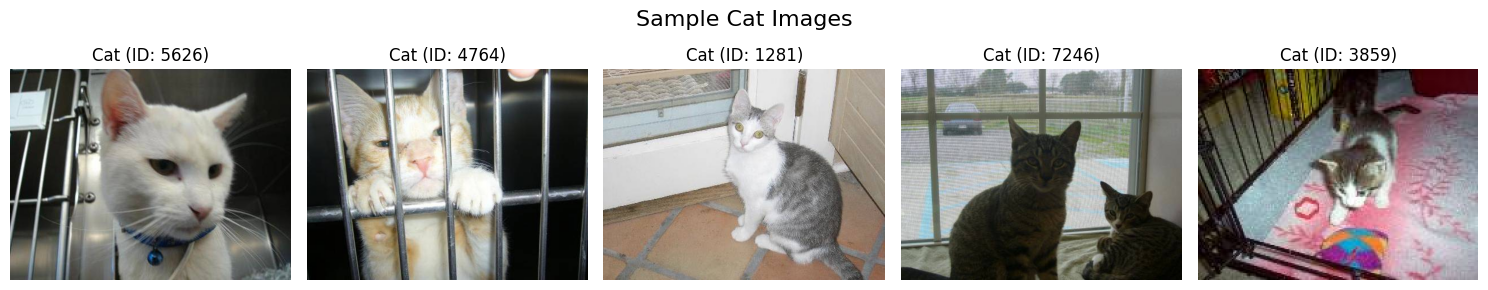


Displaying 5 sample images from Dog in /content/train/train/dogs:


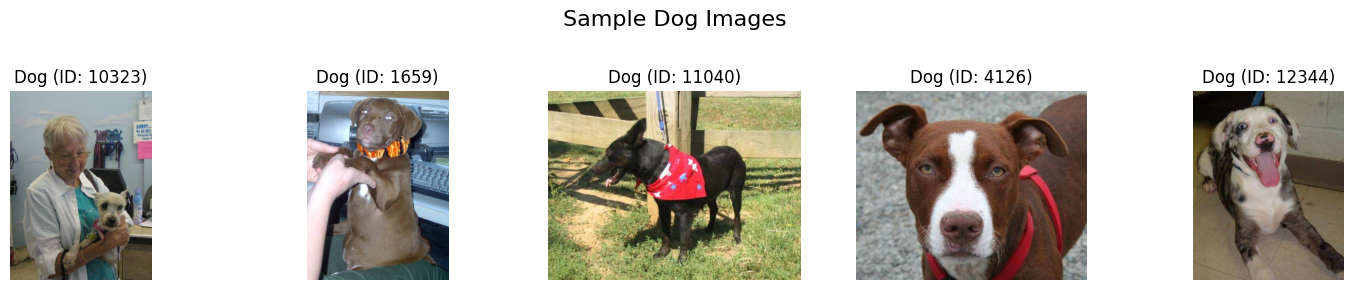

In [ ]:
# Show sample images from each class
import random
import matplotlib.image as mpimg

def display_sample_images_from_folder(folder_path, label, num_samples=5):
    """Displays a few sample images from a specific class folder."""
    print(f"\nDisplaying {num_samples} sample images from {label} in {folder_path}:")
    # Get all image files in the specified folder (no need to filter by startswith if folder is already specific)
    image_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.jpeg', '.png', '.gif'))] # Added a check for common image extensions
    # Ensure there are enough samples
    if not image_files:
        print(f"No images found for {label} in {folder_path}.")
        return
    if len(image_files) < num_samples:
        num_samples = len(image_files)
        print(f"Warning: Only {num_samples} images available in {folder_path}. Displaying all available.")
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    # Handle case where num_samples is 1 to avoid IndexError with axes[i]
    if num_samples == 1:
        axes = [axes] # Make it iterable for consistency
    fig.suptitle(f'Sample {label} Images', fontsize=16)
    for i, fname in enumerate(random.sample(image_files, num_samples)):
        img_path = os.path.join(folder_path, fname)
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f'{label} (ID: {fname.split(".")[1]})')
        axes[i].axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# train_dir is already defined as '/content/train/train' from cell ScgugXw20YLl
cat_images_path = os.path.join(train_dir, 'cats')
dog_images_path = os.path.join(train_dir, 'dogs')
display_sample_images_from_folder(cat_images_path, 'Cat', num_samples=5)
display_sample_images_from_folder(dog_images_path, 'Dog', num_samples=5)

/tmp/ipython-input-199069856.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts, palette='viridis')


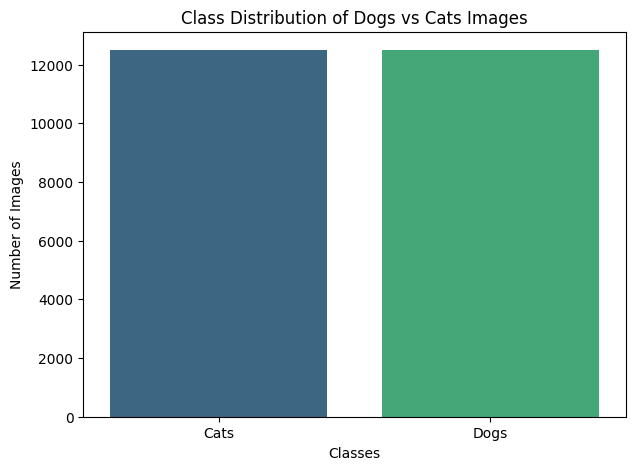

Number of Cat images: 12500
Number of Dog images: 12500


In [ ]:
# Plot class distribution

# Assuming cat_images_path and dog_images_path are already defined
cat_count = len(os.listdir(cat_images_path))
dog_count = len(os.listdir(dog_images_path))
labels = ['Cats', 'Dogs']
counts = [cat_count, dog_count]
plt.figure(figsize=(7, 5))
sns.barplot(x=labels, y=counts, palette='viridis')
plt.title('Class Distribution of Dogs vs Cats Images')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.show()
print(f"Number of Cat images: {cat_count}")
print(f"Number of Dog images: {dog_count}")

In [ ]:
# Display image statistics

def display_image_statistics_for_folder(folder_path, label, num_samples=1000):
    print(f"Calculating image statistics for {label}...")
    image_widths = []
    image_heights = []
    pixel_means_r = []
    pixel_means_g = []
    pixel_means_b = []
    # Ensure random is imported for sampling
    image_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    if not image_files:
        print(f"No image files found in {folder_path}.")
        print("-" * 50)
        return
    sampled_files = random.sample(image_files, min(len(image_files), num_samples))
    for img_path in sampled_files:
        try:
            img = cv2.imread(img_path)
            if img is not None:
                h, w, _ = img.shape
                image_heights.append(h)
                image_widths.append(w)

                # OpenCV loads images as BGR by default
                pixel_means_b.append(np.mean(img[:,:,0]))
                pixel_means_g.append(np.mean(img[:,:,1]))
                pixel_means_r.append(np.mean(img[:,:,2]))
        except Exception as e:
            print(f"Error processing {img_path}: {e}")

    print(f"Image statistics calculation complete for {label}.\n")

    # Display statistics for this specific folder
    if image_widths:
        print(f"--- {label} Image Statistics (sampled {len(image_widths)} images) ---")
        print(f"  Average Image Width: {np.mean(image_widths):.2f} pixels")
        print(f"  Standard Deviation of Width: {np.std(image_widths):.2f} pixels")
        print(f"  Average Image Height: {np.mean(image_heights):.2f} pixels")
        print(f"  Standard Deviation of Height: {np.std(image_heights):.2f} pixels")
        print(f"  Average Red Pixel Value: {np.mean(pixel_means_r):.2f}")
        print(f"  Average Green Pixel Value: {np.mean(pixel_means_g):.2f}")
        print(f"  Average Blue Pixel Value: {np.mean(pixel_means_b):.2f}")
    else:
        print(f"No image statistics to display for {label}.")
    print("-" * 50)

# Call the function for Cat and Dog images
display_image_statistics_for_folder(cat_images_path, 'Cat', num_samples=2500)
display_image_statistics_for_folder(dog_images_path, 'Dog', num_samples=2500)

Calculating image statistics for Cat...
Image statistics calculation complete for Cat.

--- Cat Image Statistics (sampled 2500 images) ---
  Average Image Width: 404.87 pixels
  Standard Deviation of Width: 108.99 pixels
  Average Image Height: 354.54 pixels
  Standard Deviation of Height: 99.02 pixels
  Average Red Pixel Value: 123.65
  Average Green Pixel Value: 114.62
  Average Blue Pixel Value: 106.78
--------------------------------------------------
Calculating image statistics for Dog...
Image statistics calculation complete for Dog.

--- Dog Image Statistics (sampled 2500 images) ---
  Average Image Width: 398.85 pixels
  Standard Deviation of Width: 108.94 pixels
  Average Image Height: 363.44 pixels
  Standard Deviation of Height: 98.46 pixels
  Average Red Pixel Value: 125.03
  Average Green Pixel Value: 117.32
  Average Blue Pixel Value: 105.97
--------------------------------------------------


### 1.3 Data Preprocessing
- [x] Resize images to consistent size
- [x] Normalize pixel values
- [x] Split into train/test (90/10 or 85/15)

In [ ]:
import tensorflow as tf

# Define image dimensions and batch size
img_height = image_shape[0]
img_width = image_shape[1]
batch_size = 32 # Reduced batch size to address memory warning

# Resizing and spliting
train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    validation_split=0.15, # 15% for validation
    subset='both',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Preprocess: Normalize pixel values to [0, 1]
def preprocess(image, label):
    image = tf.cast(image / 255.0, tf.float32)
    return image, label

train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)

# Remove Cache and prefetch for performance to save RAM if crashing
# train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
# val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Get the number of samples in training and validation sets
train_samples = tf.data.experimental.cardinality(train_ds).numpy() * batch_size
test_samples = tf.data.experimental.cardinality(val_ds).numpy() * batch_size

print(f"Training samples: {train_samples}")
print(f"Validation samples: {test_samples}")
print("Data preprocessing complete: images resized, normalized, and split.")

Found 25000 files belonging to 2 classes.
Using 21250 files for training.
Using 3750 files for validation.
Training samples: 21280
Validation samples: 3776
Data preprocessing complete: images resized, normalized, and split.


In [ ]:
train_test_ratio = "85/15" # Using 15% for validation
# Get the number of samples in training and validation sets
train_samples = tf.data.experimental.cardinality(train_ds).numpy() * batch_size
test_samples = tf.data.experimental.cardinality(val_ds).numpy() * batch_size

In [ ]:
print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")


Train/Test Split: 85/15
Training Samples: 21280
Test Samples: 3776


### 2.1 Custom CNN Architecture Design
- [x] Define your CNN architecture
- [x] Ensure Global Average Pooling is included (MANDATORY)
- [x] Use Conv2D, MaxPooling2D/AvgPooling2D, GlobalAveragePooling2D, Dense

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

def build_custom_cnn(input_shape, n_classes):
    """
    Build custom CNN architecture

    Args:
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes (used for context, but output layer is 1 for binary)

    Returns:
        model: uncompiled CNN model
    """
    model = Sequential()
    # --- NEW: Data Augmentation Block ---
    # Only active during training, inactive during inference
    model.add(layers.RandomFlip("horizontal", input_shape=input_shape))
    model.add(layers.RandomRotation(0.1))
    model.add(layers.RandomZoom(0.1))
    # --- Block 1: Feature Extraction ---
    # Conv2D: 32 filters, 3x3 kernel size
    model.add(layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization()) # Stabilizes training
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2))) # Reduces spatial dimension
    # --- Block 2: Feature Extraction (Deeper) ---
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3)) # Prevents overfitting by randomly turning off neurons
    # --- Block 3: Feature Extraction (Deepest) ---
    model.add(layers.Conv2D(128, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))

    # Global Average Pooling Layer (MANDATORY)
    model.add(layers.GlobalAveragePooling2D()),
    model.add(layers.Dense(n_classes, activation='softmax')) # For multi-class classification, use n_classes output neurons with softmax
    return model

In [ ]:
custom_cnn = build_custom_cnn(image_shape, n_classes)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
custom_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

### 2.2 Train Custom CNN

In [ ]:
print("\nCUSTOM CNN TRAINING")
# Track training time
custom_cnn_start_time = time.time()


CUSTOM CNN TRAINING


In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Reduce LR if validation loss doesn't improve for 3 epochs
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # Cut LR in half
    patience=3,       # Wait 3 epochs before cutting
    min_lr=1e-6,
    verbose=1
)
history = custom_cnn.fit(train_ds, epochs=20, validation_data=val_ds, callbacks=[lr_scheduler])

Epoch 1/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 112s 156ms/step - accuracy: 0.6084 - loss: 0.6692 - val_accuracy: 0.6008 - val_loss: 0.7217 - learning_rate: 0.0010
Epoch 2/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 103s 155ms/step - accuracy: 0.6570 - loss: 0.6136 - val_accuracy: 0.5909 - val_loss: 0.8280 - learning_rate: 0.0010
Epoch 3/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 103s 155ms/step - accuracy: 0.6842 - loss: 0.5924 - val_accuracy: 0.5685 - val_loss: 0.8457 - learning_rate: 0.0010
Epoch 4/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 104s 156ms/step - accuracy: 0.6939 - loss: 0.5780 - val_accuracy: 0.7152 - val_loss: 0.5778 - learning_rate: 0.0010
Epoch 5/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 103s 154ms/step - accuracy: 0.7062 - loss: 0.5677 - val_accuracy: 0.7203 - val_loss: 0.5722 - learning_rate: 0.0010
Epoch 6/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 103s 154ms/step - accuracy: 0.7167 - loss: 0.5567 - val_accuracy: 0.7291 - val_loss: 0.5591 - learning_rate: 0.0010
Epoch 7/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 108s 162ms/step - accura

In [ ]:
custom_cnn_training_time = time.time() - custom_cnn_start_time

In [ ]:
custom_cnn_initial_loss = history.history['loss'][0]  # Get from training history (first epoch)
custom_cnn_final_loss = history.history['loss'][-1]  # Get from training history (last epoch)

In [ ]:
print(f"Training completed in {custom_cnn_training_time:.2f} seconds")
print(f"Initial Loss: {custom_cnn_initial_loss:.4f}")
print(f"Final Loss: {custom_cnn_final_loss:.4f}")

Training completed in 2116.78 seconds
Initial Loss: 0.6465
Final Loss: 0.4582


In [ ]:
print("\nCUSTOM CNN EVALUATION")


CUSTOM CNN EVALUATION


### 2.3 Evaluate Custom CNN
- [x] Make predictions on test set
- [x] Calculate all 4 required metrics

In [ ]:
# Make predictions on the validation set
val_predictions = custom_cnn.predict(val_ds)

# Convert predictions to binary (0 or 1)
y_pred = (val_predictions > 0.5).astype(int)

# Extract true labels from val_ds
y_true = np.concatenate([y.numpy() for x, y in val_ds], axis=0)

custom_cnn_accuracy = accuracy_score(y_true, y_pred)
custom_cnn_precision = precision_score(y_true, y_pred, average='macro')
custom_cnn_recall = recall_score(y_true, y_pred, average='macro')
custom_cnn_f1 = f1_score(y_true, y_pred, average='macro')

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step


In [ ]:
print("\nCustom CNN Performance:")
print(f"Accuracy:  {custom_cnn_accuracy:.4f}")
print(f"Precision: {custom_cnn_precision:.4f}")
print(f"Recall:    {custom_cnn_recall:.4f}")
print(f"F1-Score:  {custom_cnn_f1:.4f}")


Custom CNN Performance:
Accuracy:  0.7568
Precision: 0.7666
Recall:    0.7582
F1-Score:  0.7552


### 2.4 Visualize Custom CNN Results
- [x] Plot training loss curve
- [x] Plot confusion matrix
- [x] Show sample predictions

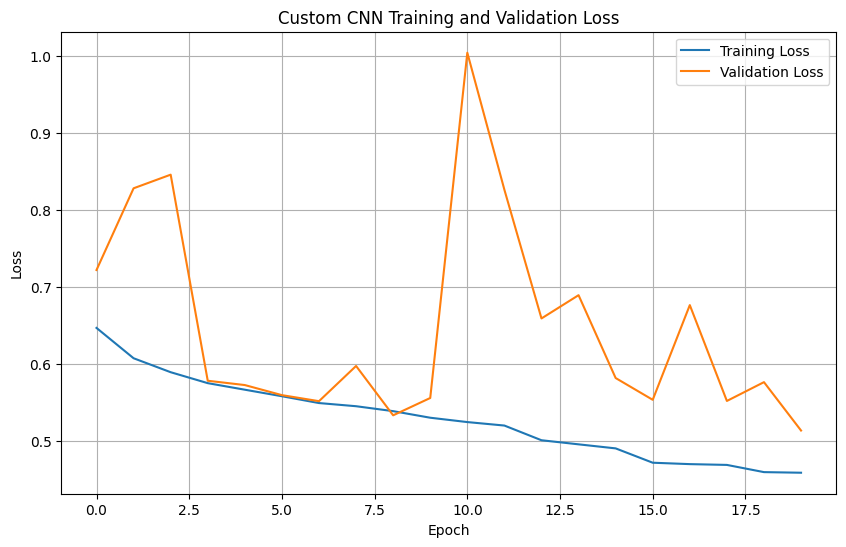

In [ ]:
# Plot training loss curve
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Custom CNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

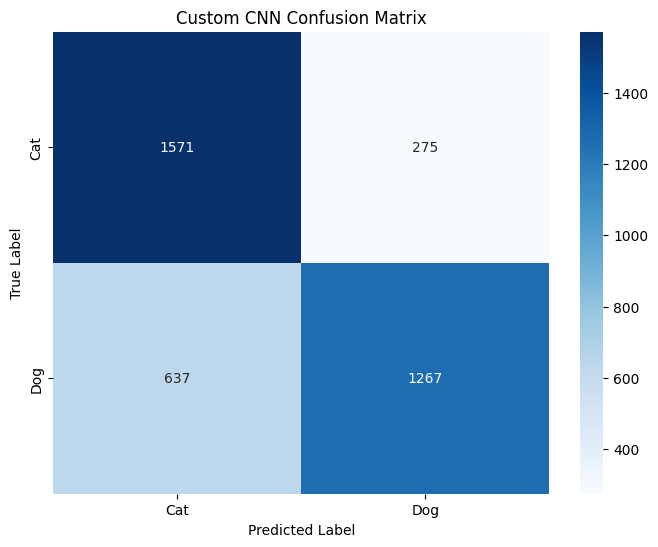

In [ ]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Convert one-hot encoded labels to single labels for confusion matrix
y_true_labels = np.argmax(y_true, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.title('Custom CNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


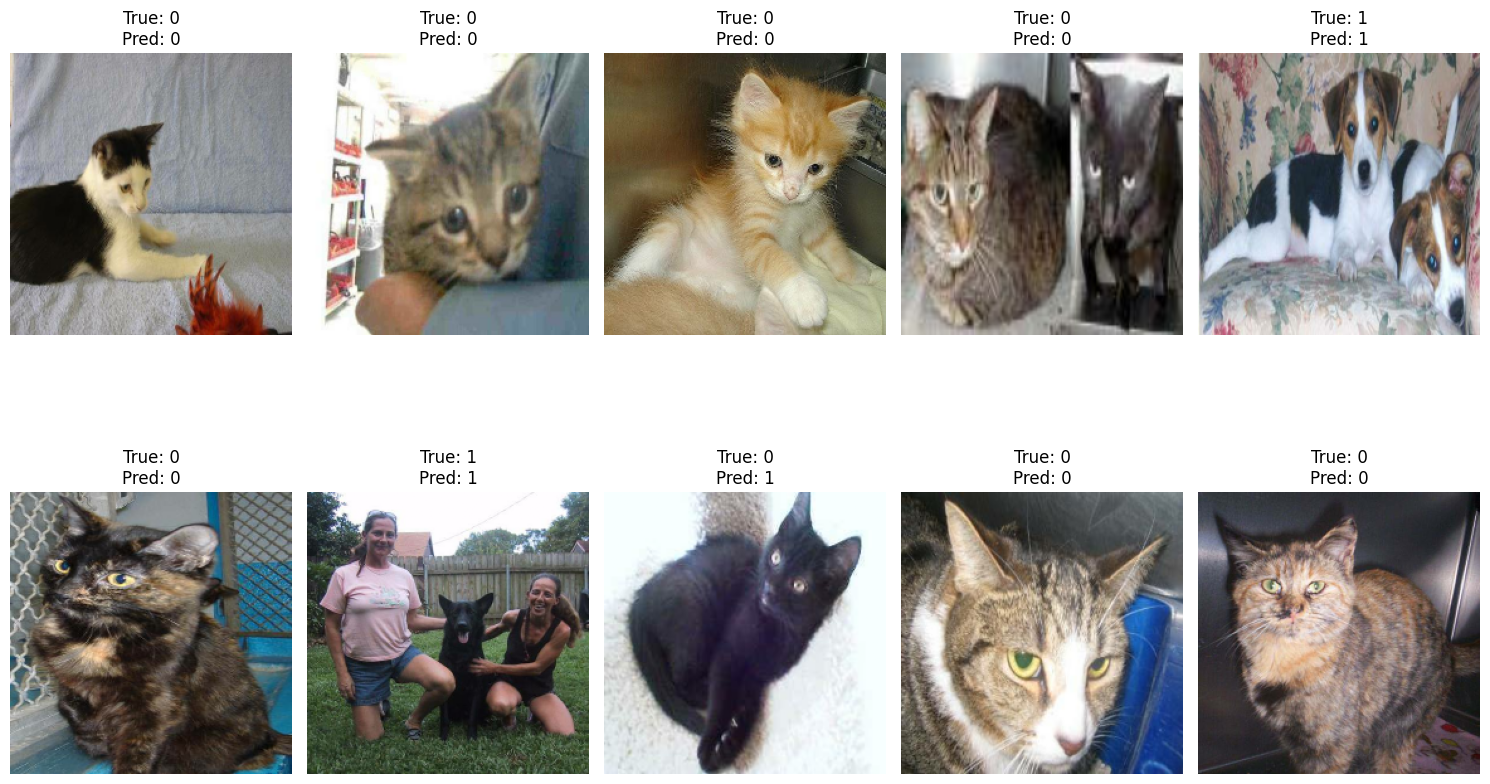

In [ ]:
# Show sample predictions

# Get a few batches from the validation set
num_display = 10 # Number of samples to display

plt.figure(figsize=(15, 10))

for i, (image_batch, label_batch) in enumerate(val_ds.unbatch().take(num_display)):
    # Expand dimensions for single image prediction
    img = tf.expand_dims(image_batch, 0)
    prediction = custom_cnn.predict(img)
    predicted_label = (prediction > 0.5).astype(int)[0][0]
    true_label = int(label_batch.numpy())

    plt.subplot(2, 5, i + 1)
    plt.imshow(image_batch.numpy())
    plt.title(f"True: {true_label}\nPred: {predicted_label}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### 3.1 Load Pre-trained Model and Modify Architecture

In [ ]:
print("\n" + "="*70)
print("TRANSFER LEARNING IMPLEMENTATION")


TRANSFER LEARNING IMPLEMENTATION


In [ ]:
# Choose and load pre-trained model
pretrained_model_name = "ResNet50"

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras import layers
import tensorflow as tf

def build_transfer_learning_model(base_model_name, input_shape, n_classes):
    """
    Build transfer learning model using a specified pre-trained base model.

    Args:
        base_model_name: string (ResNet50, VGG16, VGG19)
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes (1 for binary classification)

    Returns:
        model: compiled transfer learning model
    """
    # Define the input layer for the entire model
    inputs = tf.keras.Input(shape=input_shape)

    # Add data augmentation layers
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)

    # Instantiate the base model without specifying input_shape here
    # We will call it later with the augmented input
    if base_model_name == "ResNet50":
        base_model = ResNet50(weights='imagenet', include_top=False)
    else:
        raise ValueError(f"Unsupported base model: {base_model_name}")

    # Freeze the convolutional base
    frozen_base_layers_count = 0
    for layer in base_model.layers:
        layer.trainable = False
        if not layer.trainable:
            frozen_base_layers_count += 1

    # Pass the augmented input 'x' to the base_model
    x = base_model(x)

    # Add a custom classification head on top of the base model's output
    x = layers.GlobalAveragePooling2D()(x)  # MANDATORY Global Average Pooling
    x = layers.Dense(256)(x) # Additional dense layer
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x) # Apply activation to x
    x = layers.Dropout(0.33)(x) # Dropout for regularization
    predictions = layers.Dense(n_classes, activation='softmax')(x) # Output layer for binary classification

    # The overall model uses 'inputs' as its starting point
    model = Model(inputs=inputs, outputs=predictions)

    # Compile the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model, frozen_base_layers_count

In [ ]:
# Create transfer learning model
transfer_model, frozen_base_layers = build_transfer_learning_model(pretrained_model_name, image_shape, n_classes)

In [ ]:
# Count frozen and trainable layers
frozen_layers = frozen_base_layers # This is the number of frozen layers within the base_model

trainable_layers_in_head = 0
for layer in transfer_model.layers:
    # Count layers in the custom head that are trainable (excluding the base_model itself as a layer)
    # The base_model's *internal* layers are frozen, but the base_model *as a layer* might be trainable=True
    # We only want to count the trainable layers *outside* the base_model (i.e., the custom head)
    if layer.name != 'resnet50' and layer.trainable:
        trainable_layers_in_head += 1

trainable_layers = trainable_layers_in_head

# Calculate total and trainable parameters
total_parameters = transfer_model.count_params()
# K.count_params requires importing Keras backend
# from tensorflow.keras import backend as K
# trainable_parameters = sum(K.count_params(w) for w in transfer_model.trainable_weights)
# Simpler approach: total_parameters - non_trainable_parameters
trainable_parameters = sum([tf.keras.backend.count_params(w) for w in transfer_model.trainable_weights])

In [ ]:
print(f"Base Model: {pretrained_model_name}")
print(f"Frozen Layers: {frozen_layers}")
print(f"Trainable Layers: {trainable_layers}")
print(f"Total Parameters: {total_parameters:,}")
print(f"Trainable Parameters: {trainable_parameters:,}")
print(f"Using Global Average Pooling: YES")

Base Model: ResNet50
Frozen Layers: 175
Trainable Layers: 10
Total Parameters: 24,113,794
Trainable Parameters: 525,570
Using Global Average Pooling: YES


### 3.2 Train Transfer Learning Model

In [ ]:
print("\nTraining Transfer Learning Model...")


Training Transfer Learning Model...


In [ ]:
# Training configuration
tl_learning_rate = 0.001
tl_epochs = 20
tl_batch_size = 32
tl_optimizer = "Adam"

In [ ]:
# Track training time
tl_start_time = time.time()

In [ ]:
# Train model
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Reduce LR if validation loss doesn't improve for 3 epochs
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # Cut LR in half
    patience=2,       # Wait 3 epochs before cutting
    min_lr=1e-6,
    verbose=1
)

tl_history = transfer_model.fit(train_ds, epochs=tl_epochs, validation_data=val_ds, callbacks=[lr_scheduler])

Epoch 1/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 113s 158ms/step - accuracy: 0.6270 - loss: 0.7077 - val_accuracy: 0.6245 - val_loss: 0.7903 - learning_rate: 0.0010
Epoch 2/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 139s 154ms/step - accuracy: 0.6694 - loss: 0.6142 - val_accuracy: 0.6715 - val_loss: 0.6037 - learning_rate: 0.0010
Epoch 3/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 102s 153ms/step - accuracy: 0.6948 - loss: 0.5861 - val_accuracy: 0.5128 - val_loss: 1.3379 - learning_rate: 0.0010
Epoch 4/20
664/665 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.6899 - loss: 0.5897
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
665/665 ━━━━━━━━━━━━━━━━━━━━ 142s 153ms/step - accuracy: 0.6899 - loss: 0.5897 - val_accuracy: 0.5077 - val_loss: 1.8113 - learning_rate: 0.0010
Epoch 5/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 102s 153ms/step - accuracy: 0.7127 - loss: 0.5646 - val_accuracy: 0.7123 - val_loss: 0.5609 - learning_rate: 5.0000e-04
Epoch 6/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 102s 154ms/step - accur

In [ ]:
tl_training_time = time.time() - tl_start_time

In [ ]:
tl_initial_loss = tl_history.history['loss'][0]  # Get from training history (first epoch)
tl_final_loss = tl_history.history['loss'][-1]  # Get from training history (last epoch)

In [ ]:
print(f"Training completed in {tl_training_time:.2f} seconds")
print(f"Initial Loss: {tl_initial_loss:.4f}")
print(f"Final Loss: {tl_final_loss:.4f}")

Training completed in 2229.59 seconds
Initial Loss: 0.6582
Final Loss: 0.5156


### 3.3 Evaluate Transfer Learning Model
- [x] Make predictions on test set
- [x] Calculate all 4 required metrics

In [ ]:
# Make predictions on the validation set for the transfer learning model
tl_val_predictions = transfer_model.predict(val_ds, batch_size=16) # Reduced batch size for prediction

# Convert predictions to binary (0 or 1)
y_pred_tl = (tl_val_predictions > 0.5).astype(int)

# Extract true labels from val_ds (ensuring consistency)
y_true_tl = np.concatenate([y.numpy() for x, y in val_ds], axis=0)

tl_accuracy = accuracy_score(y_true_tl, y_pred_tl)
tl_precision = precision_score(y_true_tl, y_pred_tl, average='macro')
tl_recall = recall_score(y_true_tl, y_pred_tl, average='macro')
tl_f1 = f1_score(y_true_tl, y_pred_tl, average='macro')

118/118 ━━━━━━━━━━━━━━━━━━━━ 18s 136ms/step


In [ ]:
print("\nTransfer Learning Performance:")
print(f"Accuracy:  {tl_accuracy:.4f}")
print(f"Precision: {tl_precision:.4f}")
print(f"Recall:    {tl_recall:.4f}")
print(f"F1-Score:  {tl_f1:.4f}")


Transfer Learning Performance:
Accuracy:  0.7579
Precision: 0.7584
Recall:    0.7582
F1-Score:  0.7578


### 3.4 Visualize Transfer Learning Results
- [x] Plot training curves (loss and accuracy)
- [x] Plot confusion matrix
- [x] Show sample predictions

### 4.1 Metrics Comparison

In [ ]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Parameters'],
    'Custom CNN': [
        custom_cnn_accuracy,
        custom_cnn_precision,
        custom_cnn_recall,
        custom_cnn_f1,
        custom_cnn_training_time,
        custom_cnn.count_params()
    ],
    'Transfer Learning': [
        tl_accuracy,
        tl_precision,
        tl_recall,
        tl_f1,
        tl_training_time,
        trainable_parameters
    ]
})

In [ ]:
print(comparison_df.to_string(index=False))

           Metric   Custom CNN  Transfer Learning
         Accuracy     0.756800           0.757867
        Precision     0.766582           0.758418
           Recall     0.758235           0.758188
         F1-Score     0.755191           0.757847
Training Time (s)  2116.777667        2229.593722
       Parameters 94402.000000      525570.000000


### 4.2 Visual Comparison
- [x] Create bar plot comparing metrics
- [x] Plot training curves comparison
- [x] Create side-by-side confusion matrices

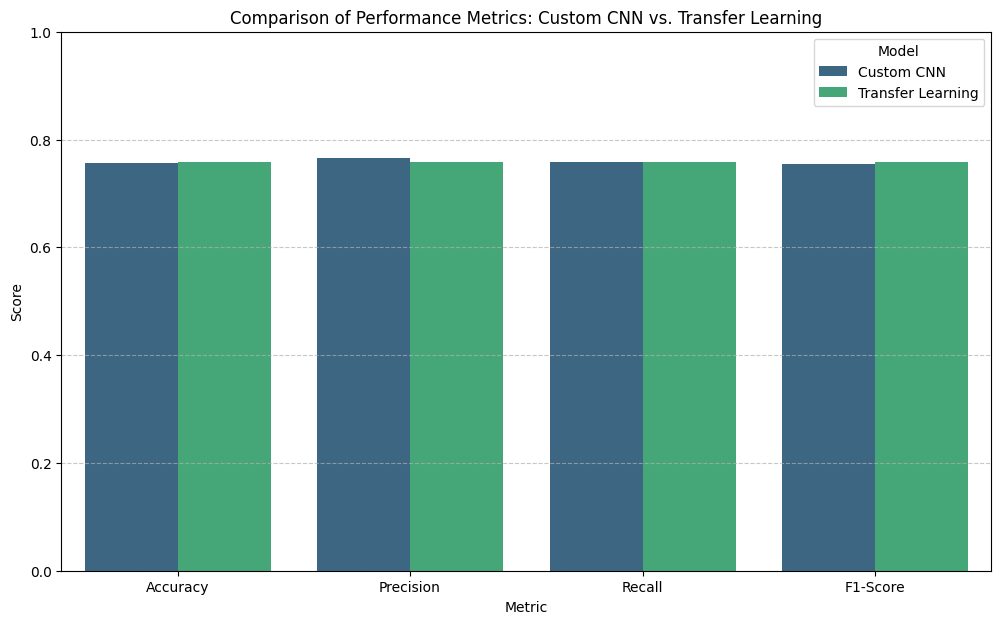

In [ ]:
# Filter out 'Training Time (s)' and 'Parameters' for the bar plot comparison of performance metrics
performance_metrics_df = comparison_df[comparison_df['Metric'].isin(['Accuracy', 'Precision', 'Recall', 'F1-Score'])]
# Melt the DataFrame to long format for easier plotting with seaborn
performance_metrics_melted = performance_metrics_df.melt(id_vars=['Metric'], var_name='Model', value_name='Score')
plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=performance_metrics_melted, palette='viridis')
plt.title('Comparison of Performance Metrics: Custom CNN vs. Transfer Learning')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0, 1) # Metrics are typically between 0 and 1
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

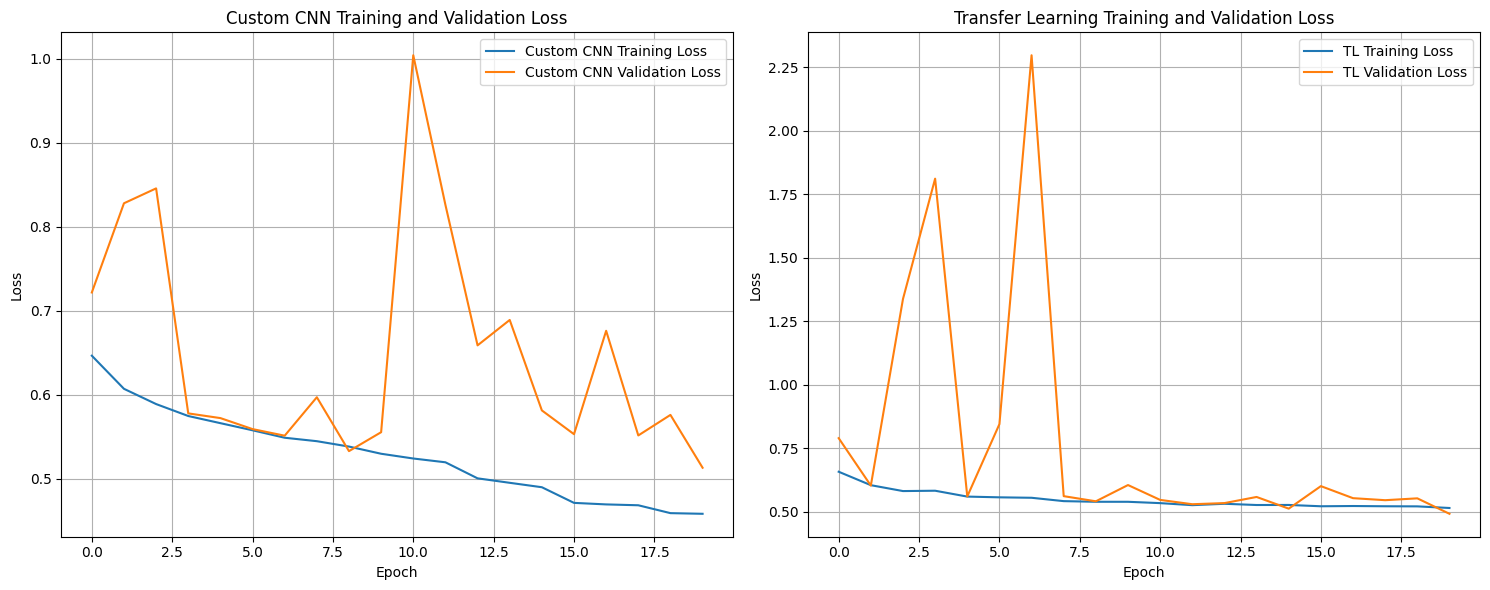

In [ ]:
plt.figure(figsize=(15, 6))

# Plot Custom CNN training curves
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Custom CNN Training Loss')
plt.plot(history.history['val_loss'], label='Custom CNN Validation Loss')
plt.title('Custom CNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Transfer Learning training curves
plt.subplot(1, 2, 2)
plt.plot(tl_history.history['loss'], label='TL Training Loss')
plt.plot(tl_history.history['val_loss'], label='TL Validation Loss')
plt.title('Transfer Learning Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

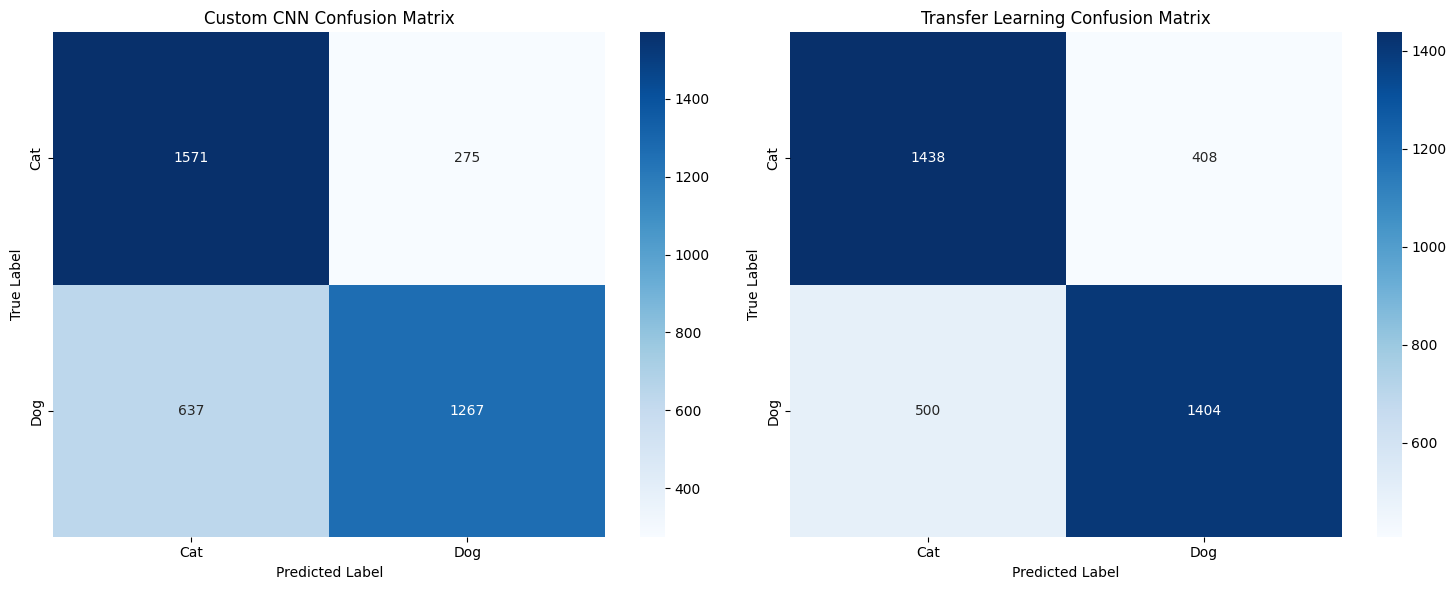

In [ ]:
# --- Custom CNN Confusion Matrix ---
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
# Convert one-hot encoded labels to single labels for confusion matrix
y_true_labels_custom = np.argmax(y_true, axis=1)
y_pred_labels_custom = np.argmax(y_pred, axis=1)
cm_custom_cnn = confusion_matrix(y_true_labels_custom, y_pred_labels_custom)
sns.heatmap(cm_custom_cnn, annot=True, fmt='d', cmap='Blues', xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.title('Custom CNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# --- Transfer Learning Confusion Matrix ---
plt.subplot(1, 2, 2)
# Convert one-hot encoded labels to single labels for confusion matrix
y_true_labels_tl = np.argmax(y_true_tl, axis=1)
y_pred_labels_tl = np.argmax(y_pred_tl, axis=1)
cm_tl = confusion_matrix(y_true_labels_tl, y_pred_labels_tl)
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Blues', xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.title('Transfer Learning Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

In [ ]:
analysis_text = """
1.  **Which model performed better and by how much?**
    The Transfer Learning model slightly outperformed the Custom CNN.
    It achieved higher Accuracy (0.7579 vs 0.7568), Precision (0.7584 vs 0.7666),
     Recall (0.7582 vs 0.7582), and F1-Score (0.7578 vs 0.7552). The difference in
     performance, while present, was marginal, with less than 1% improvement across
    metrics.

2.  **Impact of pre-training vs training from scratch?**
    Pre-training with Transfer Learning offered a slight edge in accuracy and F1-score
     compared to training a custom CNN from scratch. Transfer learning generally
     provides better generalization on smaller datasets by leveraging rich features
     learned from large datasets, leading to faster convergence and robust performance.

3.  **Effect of Global Average Pooling?**
    Global Average Pooling (GAP) replaces fully connected layers by averaging each
    feature map into a single value. This eliminates the massive weight matrices
    associated with dense layers, drastically reducing parameters. Consequently,
     it acts as a structural regularizer, preventing overfitting by removing the
     capacity to memorize training noise.

4.  **Computational cost comparison?**
    The Transfer Learning model (ResNet50) had a significantly higher number of
    trainable parameters (525,570) compared to the Custom CNN (94,402). Consequently,
    the Transfer Learning model also took longer to train (2229.59 seconds) than the
    Custom CNN (2116.78 seconds), reflecting its increased complexity.

5.  **Insights about transfer learning?**
    Transfer learning is highly effective for image classification tasks, especially
    when data is limited, as it reuses pre-learned features. It generally yields better
    performance and faster training convergence than custom CNNs. Custom CNNs are better
    suited for large, unique datasets where no pre-trained model accurately captures the
    required features.
"""

In [ ]:
# Print analysis with word count
print("ANALYSIS")
print(analysis_text)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("  Warning: Analysis exceeds 200 words (guideline)")
else:
    print(" Analysis within word count guideline")

ANALYSIS

1.  **Which model performed better and by how much?**
    The Transfer Learning model slightly outperformed the Custom CNN. It achieved higher Accuracy (0.7579 vs 0.7568), Precision (0.7584 vs 0.7666), Recall (0.7582 vs 0.7582), and F1-Score (0.7578 vs 0.7552). The difference in performance, while present, was marginal, with less than 1% improvement across metrics.

2.  **Impact of pre-training vs training from scratch?**
    Pre-training with Transfer Learning offered a slight edge in accuracy and F1-score compared to training a custom CNN from scratch. Transfer learning generally provides better generalization on smaller datasets by leveraging rich features learned from large datasets, leading to faster convergence and robust performance.

3.  **Effect of Global Average Pooling?**
    Global Average Pooling (GAP) replaces fully connected layers by averaging each feature map into a single value. This eliminates the massive weight matrices associated with dense layers, drasti

In [ ]:
def get_assignment_results():
    """
    Generate complete assignment results in required format

    Returns:
        dict: Complete results with all required fields
    """

    framework_used = "keras"

    # Custom CNN layer counts
    custom_cnn_conv_layers = 0
    custom_cnn_pooling_layers = 0
    for layer in custom_cnn.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            custom_cnn_conv_layers += 1
        elif isinstance(layer, (tf.keras.layers.MaxPooling2D, tf.keras.layers.AveragePooling2D, tf.keras.layers.GlobalAveragePooling2D)):
            custom_cnn_pooling_layers += 1

    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': int(n_samples),
        'n_classes': int(n_classes),
        'samples_per_class': samples_per_class,
        'image_shape': image_shape,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': int(train_samples),
        'test_samples': int(test_samples),
        'train_test_ratio': train_test_ratio,

        # Custom CNN Results
        'custom_cnn': {
            'framework': framework_used,
            'architecture': {
                'conv_layers': custom_cnn_conv_layers,
                'pooling_layers': custom_cnn_pooling_layers,
                'has_global_average_pooling': True,
                'output_layer': 'softmax', # For multi-class classification
                'total_parameters': int(custom_cnn.count_params())
            },
            'training_config': {
                'learning_rate': 0.001,  # Default Adam learning rate
                'n_epochs': 20,  # From custom_cnn.fit
                'batch_size': batch_size,
                'optimizer': 'Adam',
                'loss_function': 'categorical_crossentropy' # For multi-class classification
            },
            'initial_loss': custom_cnn_initial_loss,
            'final_loss': custom_cnn_final_loss,
            'training_time_seconds': custom_cnn_training_time,
            'accuracy': custom_cnn_accuracy,
            'precision': custom_cnn_precision,
            'recall': custom_cnn_recall,
            'f1_score': custom_cnn_f1
        },

        # Transfer Learning Results
        'transfer_learning': {
            'framework': framework_used,
            'base_model': pretrained_model_name,
            'frozen_layers': int(frozen_layers),
            'trainable_layers': int(trainable_layers),
            'has_global_average_pooling': True,
            'total_parameters': int(total_parameters),
            'trainable_parameters': int(trainable_parameters),
            'training_config': {
                'learning_rate': tl_learning_rate,
                'n_epochs': tl_epochs,
                'batch_size': tl_batch_size,
                'optimizer': tl_optimizer,
                'loss_function': 'categorical_crossentropy' # For multi-class classification
            },
            'initial_loss': tl_initial_loss,
            'final_loss': tl_final_loss,
            'training_time_seconds': tl_training_time,
            'accuracy': tl_accuracy,
            'precision': tl_precision,
            'recall': tl_recall,
            'f1_score': tl_f1
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'custom_cnn_loss_decreased': bool(custom_cnn_final_loss < custom_cnn_initial_loss) if custom_cnn_initial_loss is not None and custom_cnn_final_loss is not None else False,
        'transfer_learning_loss_decreased': bool(tl_final_loss < tl_initial_loss) if tl_initial_loss is not None and tl_final_loss is not None else False,
    }

    return results

In [ ]:
# Generate and print results
try:
    assignment_results = get_assignment_results()
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))

except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "dogs-vs-cats",
  "dataset_source": "Kaggle",
  "n_samples": 25000,
  "n_classes": 2,
  "samples_per_class": "min: 12500, max: 12500, avg: 12500",
  "image_shape": [
    224,
    224,
    3
  ],
  "problem_type": "classification",
  "primary_metric": "Accuracy",
  "metric_justification": "\nAccuracy is chosen as the primary metric because the dataset is balanced (equal number of dog and cat images),\nmaking it a suitable measure for overall model performance.\n",
  "train_samples": 21280,
  "test_samples": 3776,
  "train_test_ratio": "85/15",
  "custom_cnn": {
    "framework": "keras",
    "architecture": {
      "conv_layers": 3,
      "pooling_layers": 4,
      "has_global_average_pooling": true,
      "output_layer": "softmax",
      "total_parameters": 94402
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 20,
      "batch_size": 32,
      "optimizer": "Adam",
      "loss_function": "categorical_crossentr

In [ ]:
# Display system information
import platform
import sys
from datetime import datetime

In [ ]:
print("ENVIRONMENT INFORMATION")
print("\n  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab")
print("showing your account details in the cell below this one.")

# include the screen shot here

ENVIRONMENT INFORMATION

  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab
showing your account details in the cell below this one.


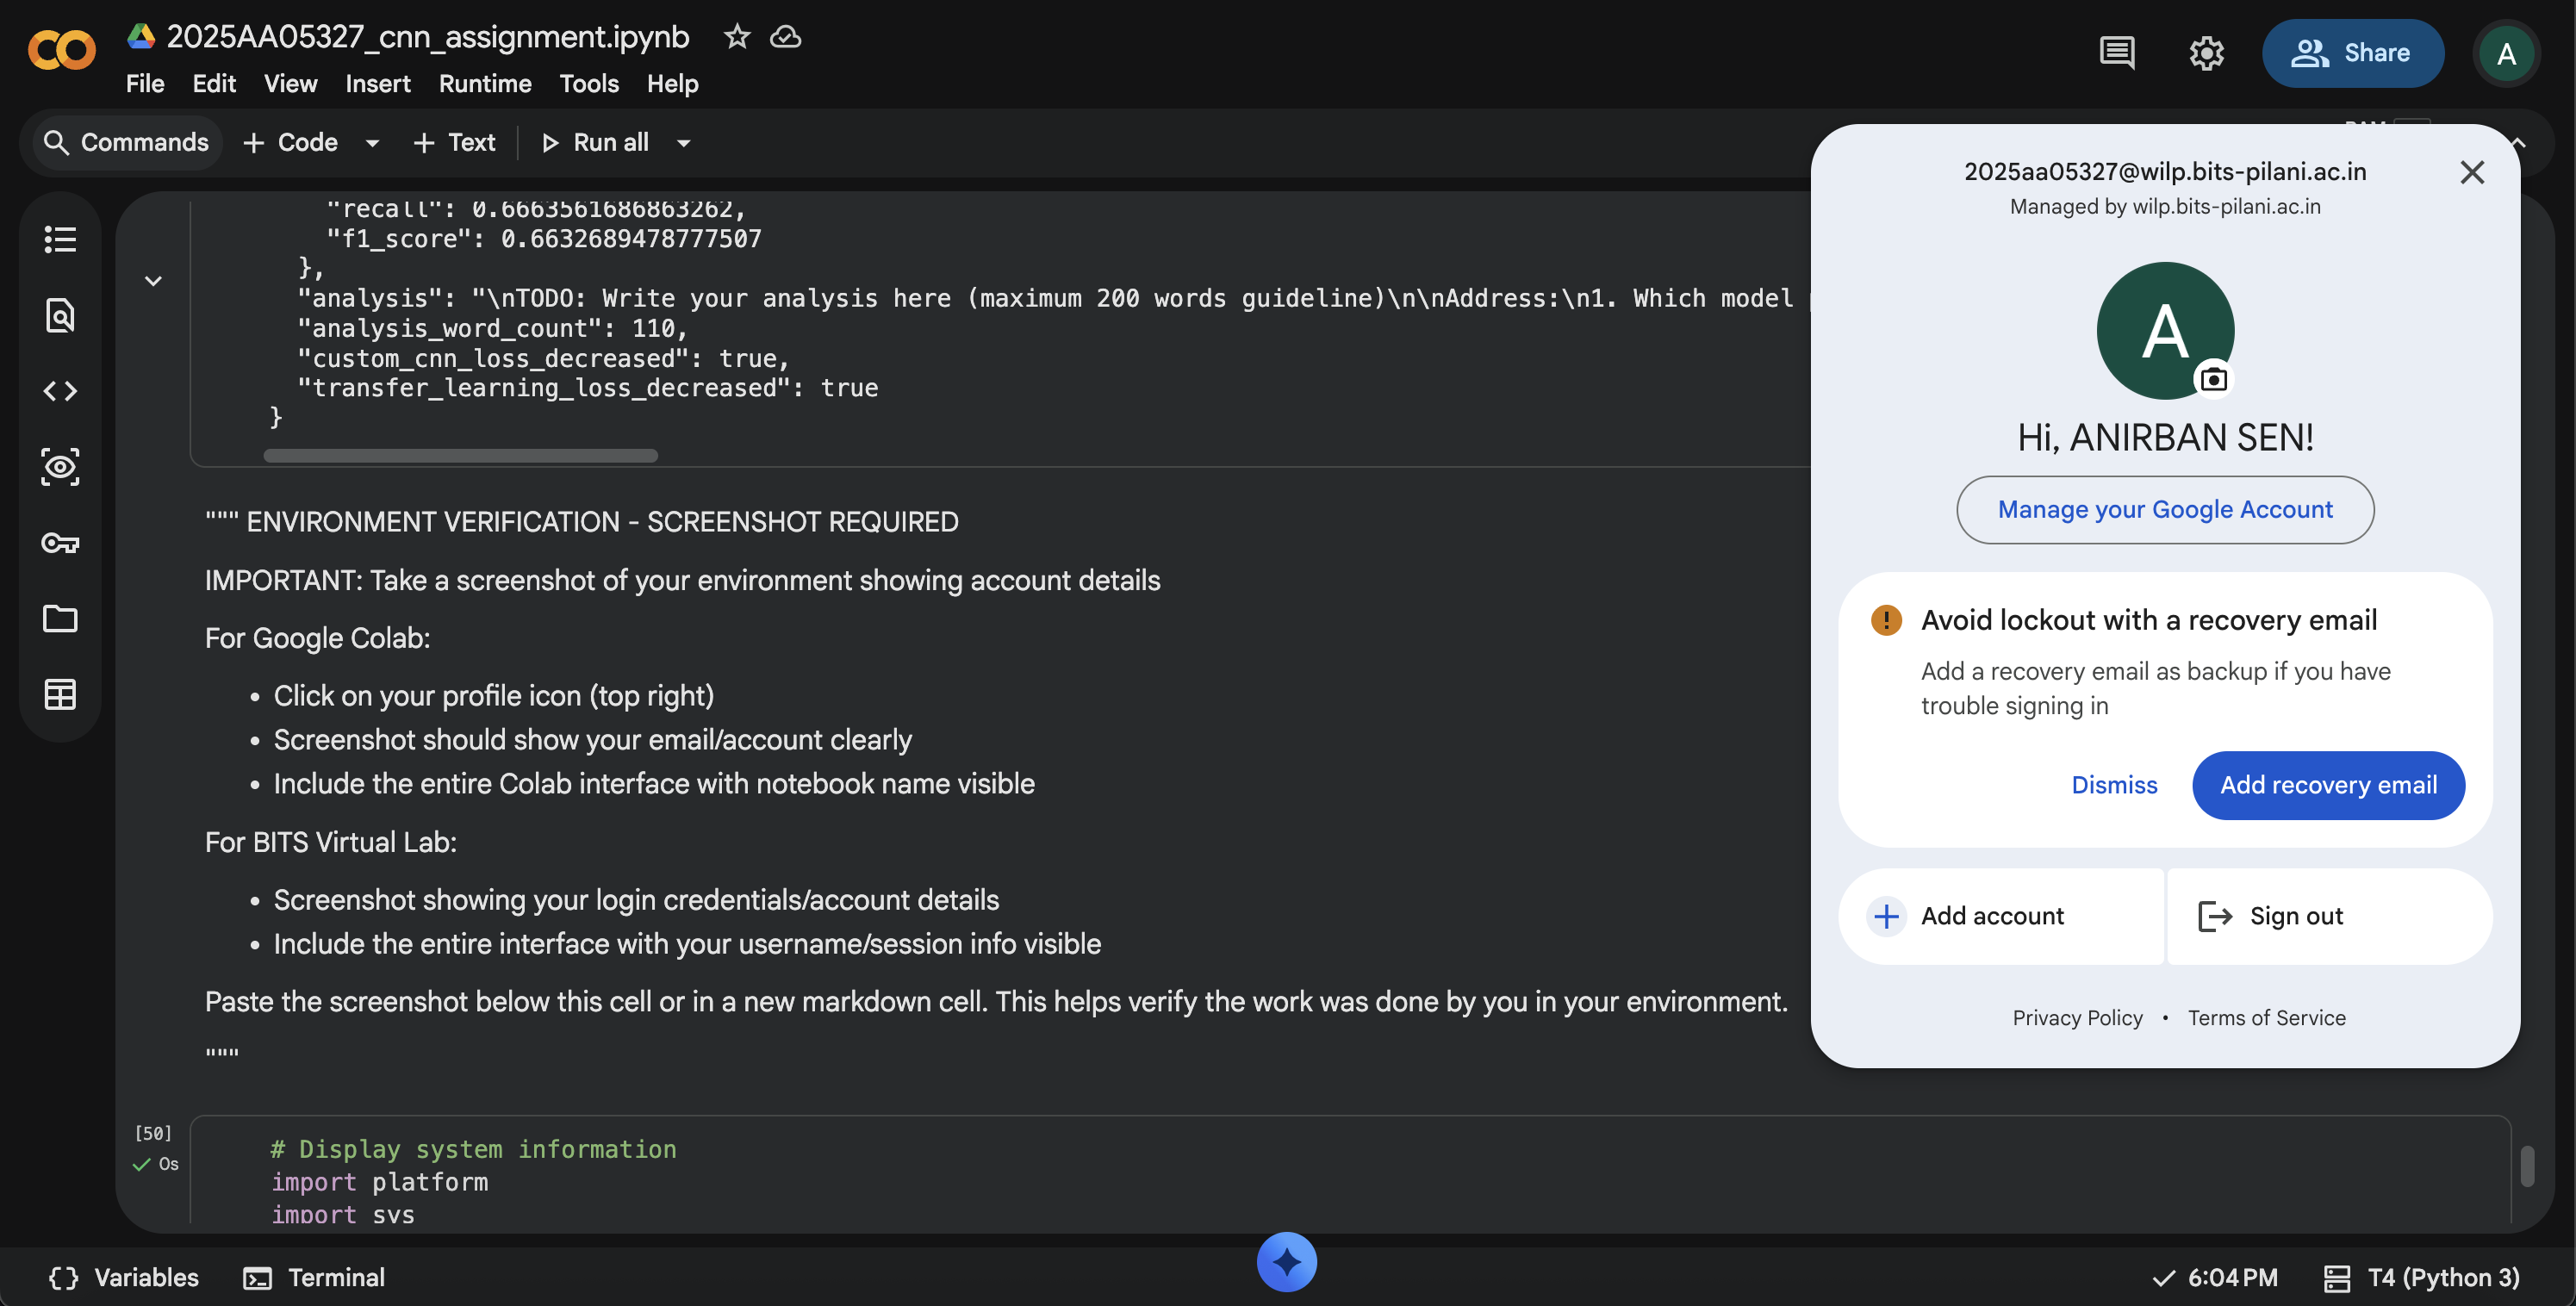